In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
np.random.seed(42)

In [ ]:
# Hämta MNIST-datasetet från OpenML
# X: innehåller pixeldata för bilderna (70000 rader och 784 kolumner för varje pixel)
# y: innehåller etiketter (0–9) som representerar siffrorna i datasetet

In [3]:
# Hämta MNIST-datasetet
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

# Definiera X och y
X = mnist["data"]
y = mnist["target"].astype(np.uint8)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Spara data och mål som NumPy-filer
np.save("X_mnist.npy",X)
np.save("y_mnist.npy", y)

# Kontrollera om några bilder är tomma (alla pixelvärden = 0)
empty_indices = np.where(X.sum(axis=1) == 0)[0]

# Skriv ut information om de tomma bilderna
print(f"Antal tomma bilder: {len(empty_indices)}")
print(f"Index för tomma bilder: {empty_indices}")

X shape: (70000, 784)
y shape: (70000,)
Antal tomma bilder: 0
Index för tomma bilder: []


In [4]:
# Ladda sparade NumPy-filer
def load_mnist_data():
    X = np.load("X_mnist.npy")  # Pixeldata
    y = np.load("y_mnist.npy").astype(np.uint8)  # Etiketter som uint8
    print(f"Data laddad: X shape = {X.shape}, y shape = {y.shape}")
    return X, y  # Returnera data och mål

# Använd funktionen för att ladda data
X, y = load_mnist_data()

Data laddad: X shape = (70000, 784), y shape = (70000,)


In [4]:
# Fördela data i tränings- och testset så att testdatan är 35% av den totala datan
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.4285, random_state=42)

# Ange antalet träningsobservationer som ska vara 25 000
train_size = 25000

# Fördela tränings- och valideringsdatan så att valideringsdatan utgör resterande del
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=train_size, random_state=42)

# Kontrollera storleken på tränings- och valideringsdatan
print(f'Train data shape: {X_train.shape}, {y_train.shape}')
print(f'Validation data shape: {X_val.shape}, {y_val.shape}')
print(f'Test data shape: {X_test.shape}, {y_test.shape}')

Train data shape: (25000, 784), (25000,)
Validation data shape: (15005, 784), (15005,)
Test data shape: (29995, 784), (29995,)


Initering och träning av modell logistik regression, resultat sparas och kan återhämtas.

In [5]:
# Skapa pipeline med StandardScaler och baseline setting.
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_jobs=-1))
])
rf_baseline = rf.fit(X_train, y_train)
score = rf.score(X_val, y_val)
joblib.dump(rf,'rf_trained.pkl')
print('Modellen är tränad')
print("RandomForestClassifier:", score)

Modellen är tränad
RandomForestClassifier: 0.9614795068310563


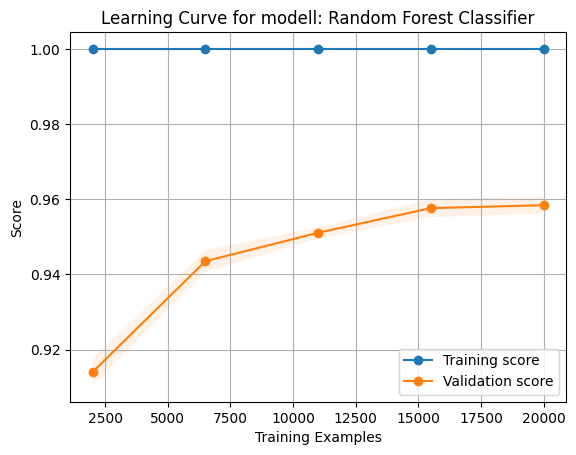

In [7]:
# Ladda den sparade pipelinen med modellen
rf= joblib.load('rf_trained.pkl')

# Funktion för att plotta inlärningskurva
def plot_learning_curve(estimator, title, X, y):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=5, n_jobs=-1)
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label='Training score')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
    plt.title(title)
    plt.xlabel('Training Examples')
    plt.ylabel('Score')
    plt.legend()
    plt.grid()
    plt.show()

# Plotta inlärningskurva för den laddade pipelinen med modellen
plot_learning_curve(rf, 'Learning Curve for modell: Random Forest Classifier', X_train, y_train)

In [ ]:
Optimering av modellen RandomForest, på 5 utvalda hyperparametrar, n_jobs =-1 körs på samtliga modeller.

In [21]:
n_estimators_list = [100, 200, 300, 400, 500]
n_estimators_scores = {}

for n_estimators in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n_estimators, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    score = f1_score(y_val, y_val_pred, average='weighted')
    n_estimators_scores[n_estimators] = score

best_n_estimators = max(n_estimators_scores, key=n_estimators_scores.get)
print(f"Bästa n_estimators: {best_n_estimators} med F1-score {n_estimators_scores[best_n_estimators]:.4f}")


Bästa antal K, neighbors: 3 med noggrannhet 0.9659


In [9]:
max_depth_list = [None, 10, 20, 30]
max_depth_scores = {}

for max_depth in max_depth_list:
    rf = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=max_depth, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    score = f1_score(y_val, y_val_pred, average='weighted')
    max_depth_scores[max_depth] = score

best_max_depth = max(max_depth_scores, key=max_depth_scores.get)
print(f"Bästa max_depth: {best_max_depth} med F1-score {max_depth_scores[best_max_depth]:.4f}")

Bästa weight-parametern: distance med poängen 1.0000


In [11]:
min_samples_split_list = [2, 5, 10]
min_samples_split_scores = {}

for min_samples_split in min_samples_split_list:
    rf = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_max_depth, min_samples_split=min_samples_split, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    score = f1_score(y_val, y_val_pred, average='weighted')
    min_samples_split_scores[min_samples_split] = score

best_min_samples_split = max(min_samples_split_scores, key=min_samples_split_scores.get)
print(f"Bästa min_samples_split: {best_min_samples_split} med F1-score {min_samples_split_scores[best_min_samples_split]:.4f}")

Bästa algoritm: auto med noggrannhet 0.9673


In [1]:
min_samples_leaf_list = [1, 2, 4]
min_samples_leaf_scores = {}

for min_samples_leaf in min_samples_leaf_list:
    rf = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_max_depth, min_samples_split=best_min_samples_split, min_samples_leaf=min_samples_leaf, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    score = f1_score(y_val, y_val_pred, average='weighted')
    min_samples_leaf_scores[min_samples_leaf] = score

best_min_samples_leaf = max(min_samples_leaf_scores, key=min_samples_leaf_scores.get)
print(f"Bästa min_samples_leaf: {best_min_samples_leaf} med F1-score {min_samples_leaf_scores[best_min_samples_leaf]:.4f}")

NameError: name 'RandomForestClassifier' is not defined

In [15]:
max_features_list = ['auto', 'sqrt', 'log2']
max_features_scores = {}

for max_features in max_features_list:
    rf = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_max_depth, min_samples_split=best_min_samples_split, min_samples_leaf=best_min_samples_leaf, max_features=max_features, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    score = f1_score(y_val, y_val_pred, average='weighted')
    max_features_scores[max_features] = score

best_max_features = max(max_features_scores, key=max_features_scores.get)
print(f"Bästa max_features: {best_max_features} med F1-score {max_features_scores[best_max_features]:.4f}")

Bästa leaf_size: 10 med valideringsnoggrannhet: 0.9673


In [8]:
# Ladda den tränade modellen
rf = joblib.load('rf_trained.pkl') 

# Gör prediktioner på valideringsdata med den optimerade modellen
y_val_pred_opt = rf.predict(X_val)

# Utvärdera modellens prestanda
accuracy_opt = accuracy_score(y_val, y_val_pred_opt)
precision_opt = precision_score(y_val, y_val_pred_opt, average='macro')
recall_opt = recall_score(y_val, y_val_pred_opt, average='macro')
f1_opt = f1_score(y_val, y_val_pred_opt, average='weighted')

# Samla resultaten
rf_results = [{
    'Model': 'RandomForestClassifier ',
    'Accuracy': accuracy_opt,
    'Precision': precision_opt,
    'Recall': recall_opt,
    'F1-score': f1_opt
}]

# Spara resultaten
joblib.dump(rf_results, 'rf_results.pkl')

# Konvertera listan till en DataFrame och visa resultaten
rf_results = pd.DataFrame(rf_results)
rf_results

,Model,Accuracy,Precision,Recall,F1-score
0,RandomForestClassifier,0.96148,0.961107,0.96115,0.961463


In [9]:
# Ladda den sparade modellen
rf= joblib.load('rf_trained.pkl')

# Definiera scorer
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# Beräkna cross-validation scores
cv_results = cross_validate(rf, X_train, y_train, cv=5, scoring=scoring)

# Skapa en lista med resultaten
rf_results = []
for fold in range(5):
   rf_results.append({
        'Fold': fold,
        'Accuracy': cv_results['test_accuracy'][fold],
        'Precision': cv_results['test_precision'][fold],
        'Recall': cv_results['test_recall'][fold],
        'F1-score': cv_results['test_f1'][fold]
    })

# Konvertera listan till en DataFrame
rf_results = pd.DataFrame(rf_results)

# Spara DataFrame med joblib
joblib.dump(rf_results, 'rf_cv_results.pkl')

# Visa DataFrame
rf_results

,Fold,Accuracy,Precision,Recall,F1-score
0,0,0.9578,0.957809,0.957488,0.957593
1,1,0.9624,0.962218,0.962521,0.962340
2,2,0.9606,0.960662,0.960238,0.960362
3,3,0.9560,0.955616,0.955678,0.955575
4,4,0.9610,0.960689,0.960453,0.960531


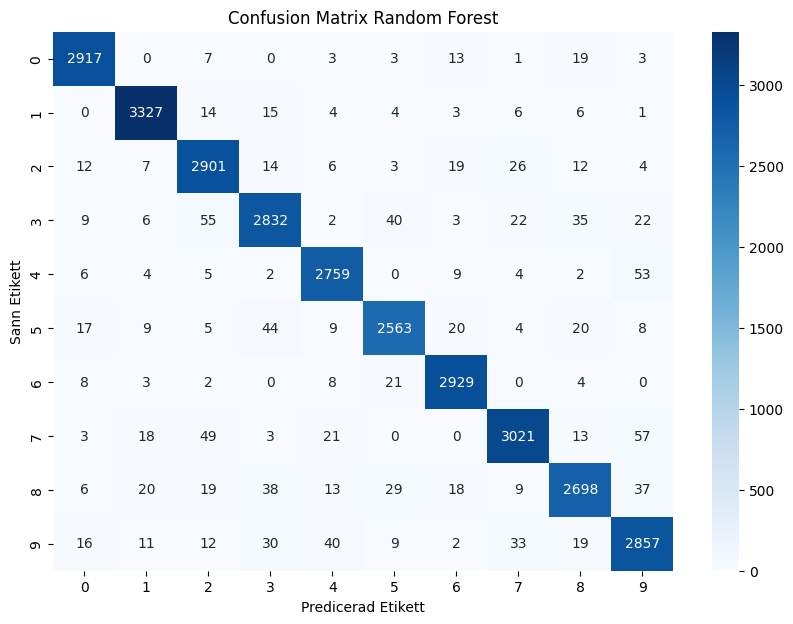

In [10]:
# Ladda tränade modell
rf = joblib.load('rf_trained.pkl')

# Gör prediktioner på testdata
y_test_pred = rf.predict(X_test)

# Skapa Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Visualisera Confusion Matrix som en heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicerad Etikett')
plt.ylabel('Sann Etikett')
plt.show()

In [12]:
cm = confusion_matrix(y_test, y_test_pred)
print("Misstag mellan 7 och 9:", cm[7, 9])
print("Misstag mellan 9 och 7:", cm[9, 7])
print('Största andelen prediktionsdel, :',57/25000)

Misstag mellan 7 och 9: 57
Misstag mellan 9 och 7: 33
Största andelen prediktionsdel, : 0.00228


Visualisering prediktion, på en handful MNIST-bilder, modell: RandomForest


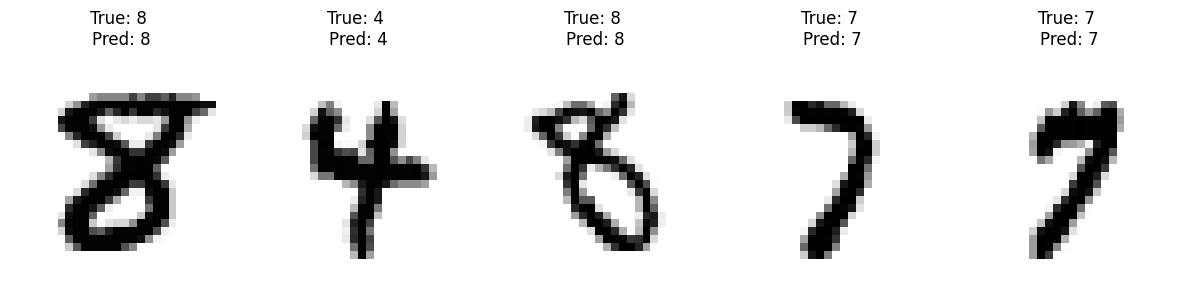

In [13]:
# Ladda tränade modell
rf = joblib.load('rf_trained.pkl')

def plot_predictions(images, true_labels, predicted_labels, n=5):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='binary')
        plt.title(f"True: {true_labels[i]} \nPred: {predicted_labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Välj exempeldata
examples = 5
X_example = X_test[:examples]
y_true_example = y_test[:examples]

# Gör prediktioner med 
y_pred_example = rf.predict(X_example)

# Visa bilderna och prediktionerna
print('Visualisering prediktion, på en handful MNIST-bilder, modell: RandomForest')
plot_predictions(X_example, y_true_example, y_pred_example)